# Adult Income Dataset Exploration

Exploring the UCI Adult Income dataset before building the ML pipeline.

Goals:
- Understand the data structure and distributions
- Identify class imbalance
- Find missing values and outliers
- Understand feature relationships with the target

In [1]:
import sys
sys.path.insert(0, '..')

from src.data.ingestion import DataIngestion
from src.data.validation import DataValidator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ingestion = DataIngestion()
df        = ingestion.load()

print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

2026-07-01 13:03:15 | INFO | src.data.ingestion | Using cached dataset
2026-07-01 13:03:15 | INFO | src.data.ingestion | Dataset loaded
Shape: (32561, 15)

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

First 5 rows:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


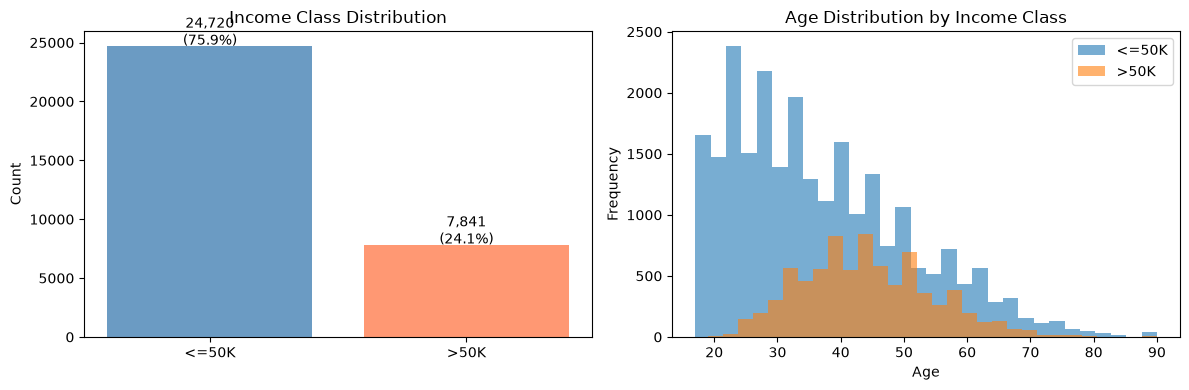


Class imbalance ratio: 3.15:1


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
target_counts = df["income"].value_counts()
axes[0].bar(target_counts.index, target_counts.values,
            color=["steelblue", "coral"], alpha=0.8)
axes[0].set_title("Income Class Distribution")
axes[0].set_ylabel("Count")
for i, (label, count) in enumerate(target_counts.items()):
    axes[0].text(i, count + 100, f"{count:,}\n({100*count/len(df):.1f}%)",
                ha='center', fontsize=10)

# Age distribution by income
df.groupby("income")["age"].plot(kind="hist", bins=30, alpha=0.6,
                                  ax=axes[1], legend=True)
axes[1].set_title("Age Distribution by Income Class")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.savefig("../data/eda_target_distribution.png", dpi=150)
plt.show()

print(f"\nClass imbalance ratio: {target_counts.max()/target_counts.min():.2f}:1")

Missing values:
  workclass: 1836 (5.6%)
  occupation: 1843 (5.7%)
  native_country: 583 (1.8%)


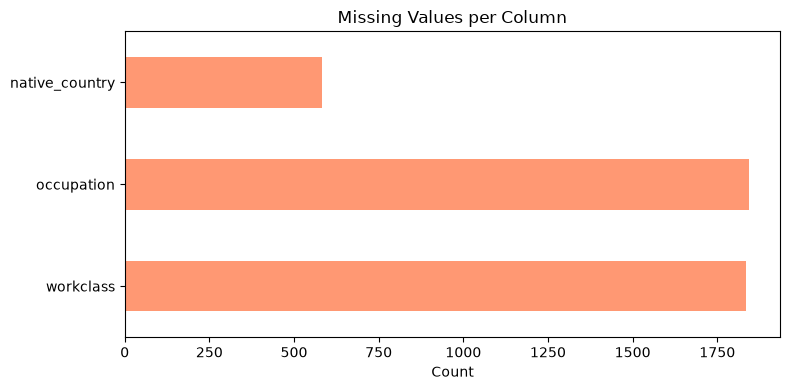

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0]

print("Missing values:")
for col, count in missing.items():
    print(f"  {col}: {count} ({100*count/len(df):.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
missing.plot(kind="barh", ax=ax, color="coral", alpha=0.8)
ax.set_title("Missing Values per Column")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("../data/eda_missing_values.png", dpi=150)
plt.show()

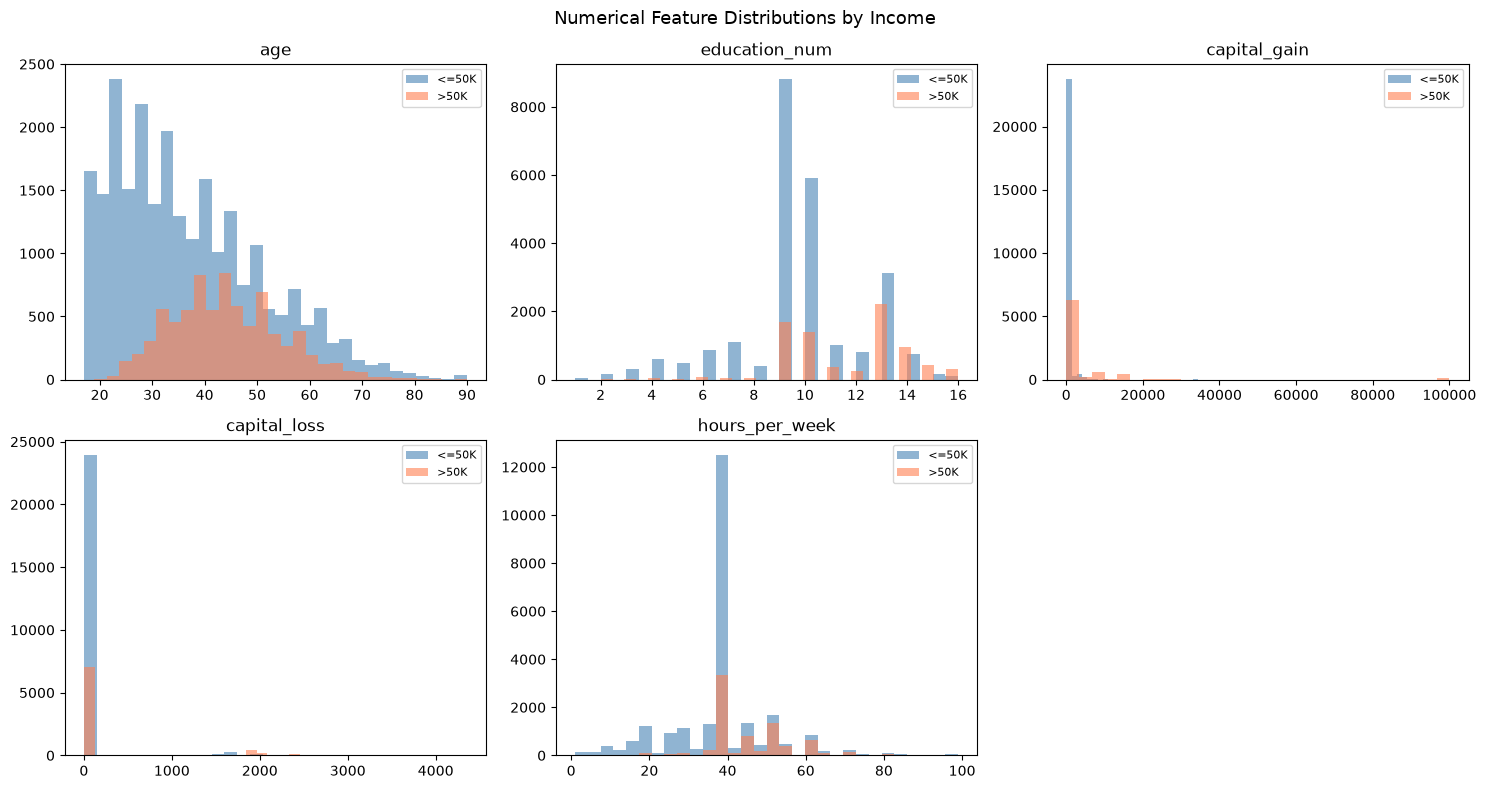

In [4]:
numerical = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Numerical Feature Distributions by Income", fontsize=13)
axes = axes.flatten()

for i, col in enumerate(numerical):
    for income_class, color in [("<=50K", "steelblue"), (">50K", "coral")]:
        subset = df[df["income"] == income_class][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=income_class, color=color)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig("../data/eda_numerical_distributions.png", dpi=150)
plt.show()

In [5]:
validator = DataValidator()
report    = validator.validate(df)

print(f"Validation passed: {report['passed']}")
print(f"Errors:   {report['errors']}")
print(f"Warnings: {report['warnings']}")
print(f"\nDataset stats:")
for k, v in report['stats'].items():
    print(f"  {k}: {v}")

2026-07-01 13:04:33 | INFO | src.data.validation | Data validation passed
2026-07-01 13:04:33 | WARNING | src.data.validation | Validation warning: Column 'workclass' has 5.6% missing values
2026-07-01 13:04:33 | WARNING | src.data.validation | Validation warning: Column 'occupation' has 5.7% missing values
Validation passed: True
Errors:   []
Warnings: ["Column 'workclass' has 5.6% missing values", "Column 'occupation' has 5.7% missing values"]

Dataset stats:
  row_count: 32561
  column_count: 15
  missing_values: 4262
  duplicate_rows: 24
  target_distribution: {'<=50K': 0.7591904425539756, '>50K': 0.2408095574460244}


## Key Findings

1. **Class imbalance**: 76% earn ≤$50K, 24% earn >$50K — 3:1 ratio
   This means accuracy alone is misleading — a model predicting all ≤$50K
   gets 76% accuracy but is completely useless. We use ROC-AUC and F1.

2. **Missing values**: workclass (5.6%) and occupation (5.7%) have missing values
   marked as "?" in the original data. We impute with most frequent value.

3. **Capital gain/loss are sparse**: most values are 0, with a few very large values.
   This skewed distribution makes these features tricky but informative.

4. **Education and education_num are redundant**: education_num is the numerical
   encoding of education. We keep education_num and drop education.